### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

np.float64(1.0863332746425673)

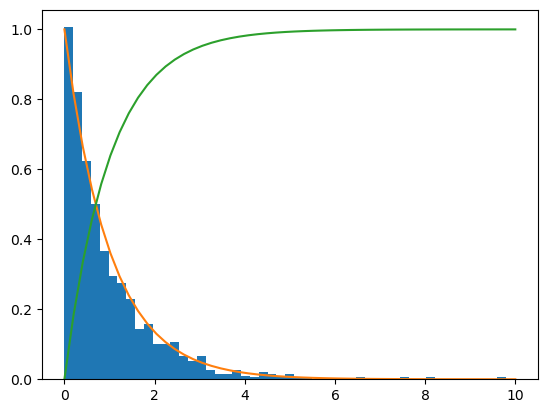

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

dist = sp.stats.gamma(1)

x = np.random.gamma(shape=1, scale=1, size=1000)
plt.hist(x=x, density=True, bins=50)

y = np.linspace(0, 10)
plt.plot(y, dist.pdf(y), label='PDF')
shape, location, scale = sp.stats.gamma.fit(x)
shape

plt.plot(y, dist.cdf(y), label='CDF')

varianza = np.var(x); varianza


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

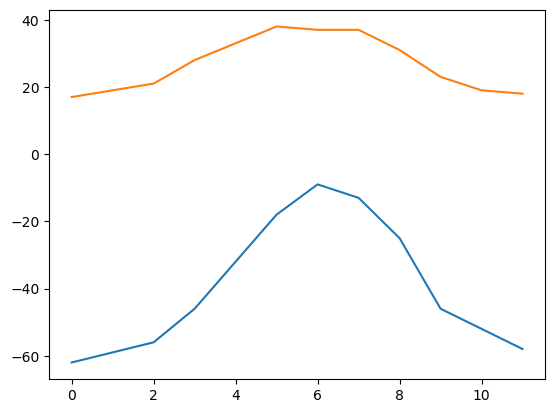

In [53]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt
import scipy as sp

months = np.arange(12)
plt.plot(months, temp_min)
plt.plot(months, temp_max)


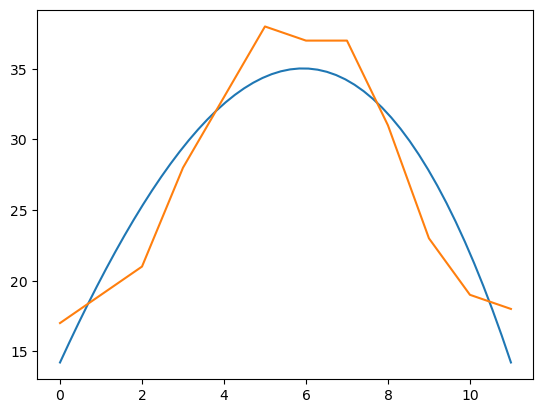

In [ ]:
#devo definire la funzione con cui voglio fittare
def polinomio_grado_3(x, a, b, c, d):
    return a*x**3+b*x**2+c*x+d

#calcolo i parametri
parametri_max, _ = sp.optimize.curve_fit(polinomio_grado_3, xdata=months, ydata=temp_max)
parametri_min, _ = sp.optimize.curve_fit(polinomio_grado_3, xdata=months, ydata=temp_min)

#plotto il grafico e ci sovrappongo quello di prima
x = np.linspace(0,11)
plt.plot(x, polinomio_grado_3(x, *parametri_max)) #uso il * per fare unpack dell'array parametri max (che contiene a,b,c,d)
plt.plot(months, temp_max)


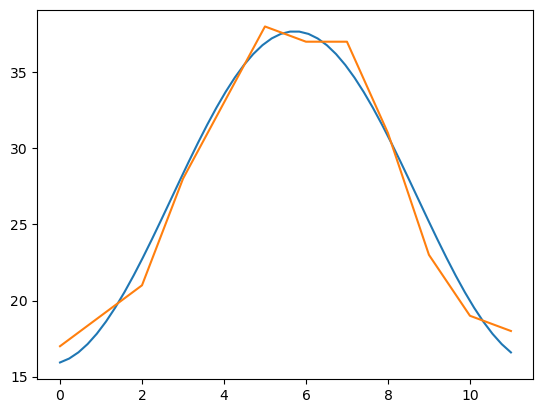

In [61]:
#faccio anche con fit
def sin(x,a,b,c):
    return c+a*np.sin((x+b)*2*np.pi/12)

#calcolo i parametri
parametri_max, _ = sp.optimize.curve_fit(sin, xdata=months, ydata=temp_max)
# parametri_min, _ = sp.optimize.curve_fit(sin, xdata=months, ydata=temp_min)

#plotto il grafico e ci sovrappongo quello di prima
x = np.linspace(0,11)
plt.plot(x, sin(x, *parametri_max)) #uso il * per fare unpack dell'array parametri max (che contiene a,b,c,d)
plt.plot(months, temp_max)


### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [63]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df



,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


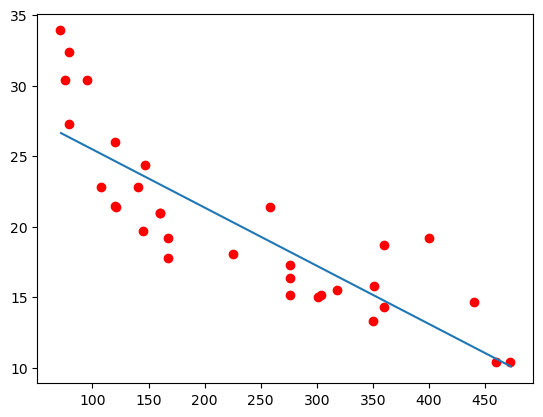

In [ ]:
slope, intercept, r_value, p_value, std_err = sp.stats.linregress(df["disp"], df["mpg"]) #attenta a quale vuoi prevedere!!!!!
y_fit_sp = slope * x + intercept

min(df["disp"]) #71.1
max(df["disp"]) #472
x = np.linspace(72, 473)
plt.plot(df["disp"], df["mpg"], "ro")
plt.plot(x, y_fit_sp)